In [2]:
import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import random

In [4]:
# Basic Pauli matrices
I_mat = np.array([[1, 0], [0, 1]], dtype=complex)
X_mat = np.array([[0, 1], [1, 0]], dtype=complex)
Y_mat = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z_mat = np.array([[1, 0], [0, -1]], dtype=complex)

def mkron(*args):
    """Helper to compute Kronecker product of a list of matrices."""
    res = args[0]
    for op in args[1:]:
        res = np.kron(res, op) 
    return res

def get_op(op, j, N):
    """Places operator 'op' on qubit 'j' in an N-qubit system."""
    ops = [I_mat] * N
    ops[j] = op
    return mkron(*ops)

def state_to_dm(psi_list):
    """Converts a list of single-qubit states into an N-qubit density matrix."""
    psi_full = mkron(*psi_list)
    return np.outer(psi_full, psi_full.conj())

st_z_plus = np.array([1, 0], dtype=complex)
st_z_minus = np.array([0, 1], dtype=complex)
st_y_plus = np.array([1, 1j]) / np.sqrt(2)
st_y_minus = np.array([1, -1j]) / np.sqrt(2)
st_x_plus = np.array([1, 1]) / np.sqrt(2)
st_x_minus = np.array([1, -1]) / np.sqrt(2)

# ---------------------------------------------------------
# NEW: Dynamic Operator Generator
# ---------------------------------------------------------
def generate_operators(N):
    """Dynamically generates the system operators for N qubits."""
    W_X_n  = [get_op(X_mat, j, N) for j in range(N)]
    W_YY_n = [get_op(Y_mat, j, N) @ get_op(Y_mat, j+1, N) for j in range(N - 1)]
    Z_ops_n = [get_op(Z_mat, j, N) for j in range(N)]
    return W_X_n, W_YY_n, Z_ops_n

# ---------------------------------------------------------
# NEW: Dynamic True Hamiltonian Generator
# ---------------------------------------------------------
def true_Omega_X(j, t):
    return 1.0 + 0.5 * np.cos(2 * np.pi * 0.5 * t + j)

def true_J_YY(j, t):
    return 0.5 + 0.2 * t * (j % 2 == 0)

# We update this so it can read the dynamically sized operators
def H_true_func(t):
    # This uses the W_X and W_YY variables that are currently active in the global scope 
    # (which will be updated by our loop!)
    H_t = sum([true_Omega_X(j, t) * W_X[j] for j in range(len(W_X))])
    H_t += sum([true_J_YY(j, t) * W_YY[j] for j in range(len(W_YY))])
    return H_t

In [5]:
def simulate_weak_measurements(N, H_func, rho0, T_final, dt, g, N_s):
    num_steps = int(np.round(T_final / dt))
    t_grid = np.linspace(0, T_final, num_steps)
    
    """Precompute Dephasing Matrix M"""
    M1 = np.array([[1.0, np.exp(-g**2/2)],
                   [np.exp(-g**2/2), 1.0]], dtype=complex)
    M = M1
    for _ in range(N - 1): 
        M = np.kron(M, M1)
        
    """Z_ops are already precomputed globally in the initialization section"""
    
    """Simulation Loop"""
    rho = rho0.copy()
    z_ideal = np.zeros((num_steps, N))
    
    for i, t in enumerate(t_grid):
        for q in range(N):
            z_ideal[i, q] = np.real(np.trace(Z_ops[q] @ rho))
            
        """Time-dependent unitary update"""
        H_mid = H_func(t + dt / 2.0)
        U = la.expm(-1j * H_mid * dt)
        U_dag = U.conj().T
        
        rho = U @ rho @ U_dag     
        rho = np.multiply(M, rho) 
        
    """Add Gaussian Noise"""
    noise_std = np.sqrt((g**2 + 1) / (g**2 * N_s))
    z_noisy = z_ideal + np.random.normal(0, noise_std, size=z_ideal.shape)
    
    return t_grid, z_ideal, z_noisy

In [ ]:
# ---------------------------------------------------------
" Experiment Parameters"
# ---------------------------------------------------------
n_list = [2, 4, 6, 8] 
N_total_list = [int(1e6), int(1e7), int(1e8), int(1e9), int(1e10)]
R_trials = 10  

# We simulate up to 1.0s, but ONLY integrate the error up to T_eval!
T_rec = 1.0    
T_eval = 0.3   
dt = 0.02      

num_steps = int(np.round(T_rec / dt))
eval_steps = int(np.round(T_eval / dt))
plot_times = np.linspace(0, T_rec, num_steps, endpoint=False)

fixed_window = 21 
polyorder = 3
Gamma_d = 0.001
g_weak = np.sqrt(2 * Gamma_d * dt)


# We will use the 9 optimal states + K_random padding states
K_random = 11 
S_states = 9 + K_random # Total states = 20 (Constant for all n!)

mean_errors = {n: [] for n in n_list}
std_errors = {n: [] for n in n_list}
alpha_fits = {}

print("Starting Hybrid Sample Complexity Experiment...")

for n_qubits in n_list:
    print(f"\n{'='*40}\n--- Running for n = {n_qubits} (S = {S_states}) ---\n{'='*40}")
    
    W_X, W_YY, Z_ops = generate_operators(n_qubits) 
    
    def get_neighborhood(j):
        N_j = [('X', j, W_X[j])]
        if j > 0: N_j.append(('YY', j-1, W_YY[j-1]))
        if j < n_qubits - 1: N_j.append(('YY', j, W_YY[j]))
        return N_j

    # --- GENERATE THE 9 OPTIMAL STATES ---
    initial_rhos = []
    
    def create_optimal_probe(target_color, local_pattern):
        state_list = []
        for i in range(n_qubits):
            if i % 3 == target_color:
                state_list.append(local_pattern[1])  
            elif i % 3 == (target_color - 1) % 3:
                state_list.append(local_pattern[0])  
            elif i % 3 == (target_color + 1) % 3:
                state_list.append(local_pattern[2])  
        return state_to_dm(state_list)

    p_local_field = (st_x_plus, st_y_plus, st_x_plus)
    p_left_couple = (st_y_minus, st_x_plus, st_z_plus)
    p_right_couple = (st_z_plus, st_x_plus, st_y_minus)

    for color in range(3):
        initial_rhos.append(create_optimal_probe(color, p_local_field))
        initial_rhos.append(create_optimal_probe(color, p_left_couple))
        initial_rhos.append(create_optimal_probe(color, p_right_couple))
        
    # --- PAD WITH K RANDOM PAULI STATES ---
    np.random.seed(42)
    random.seed(42)
    pauli_states = [st_x_plus, st_x_minus, st_y_plus, st_y_minus, st_z_plus, st_z_minus]
    
    for _ in range(K_random):
        state_list = [random.choice(pauli_states) for _ in range(n_qubits)]
        initial_rhos.append(state_to_dm(state_list))

    # --- Precomputations ---
    precomputed_comms = {}
    for j in range(n_qubits):
        precomputed_comms[j] = []
        for m_idx, (term_type, term_index, W_m) in enumerate(get_neighborhood(j)):
            precomputed_comms[j].append(Z_ops[j] @ W_m - W_m @ Z_ops[j])

    ones_mat = np.ones((2**n_qubits, 2**n_qubits), dtype=complex)
    euler_diss_mask = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
    for j in range(n_qubits):
        mask_j = Z_ops[j] @ ones_mat @ Z_ops[j]
        euler_diss_mask += (Gamma_d / 2.0) * (mask_j - 1.0)

    # ---------------------------------------------------------
    "Experiment loop"
    # ---------------------------------------------------------
    for N_total in N_total_list:
        trial_errors = []
        
        # Fair Distribution: Total budget is spread across our fixed 20 states
        N_s = int(N_total / S_states) 
        
        for r in range(R_trials):
            
            z_data_noisy = np.zeros((S_states, n_qubits, num_steps))
            for s in range(S_states):
                _, _, z_noisy = simulate_weak_measurements(n_qubits, H_true_func, initial_rhos[s], T_rec, dt, g_weak, N_s)
                z_data_noisy[s, :, :] = z_noisy.T 
            
            dz_dt_smoothed = np.zeros_like(z_data_noisy)
            for s in range(S_states):
                for j in range(n_qubits):
                    dz_dt_smoothed[s, j, :] = savgol_filter(
                        z_data_noisy[s, j, :], fixed_window, polyorder, deriv=1, delta=dt)
            
            theta_X_rec = np.zeros((n_qubits, num_steps - 1))
            theta_YY_rec = np.zeros((n_qubits - 1, num_steps - 1))
            rec_rhos = [np.array(rho.copy(), dtype=complex) for rho in initial_rhos]
            
            for t_idx in range(1, num_steps - 1):  
                local_estimates = {'X': {i: [] for i in range(n_qubits)}, 
                                   'YY': {i: [] for i in range(n_qubits - 1)}}
                
                for j in range(n_qubits):
                    N_j = get_neighborhood(j)
                    M_j = np.zeros((S_states, len(N_j)), dtype=float) 
                    dSigma_j = np.zeros(S_states)
                    
                    for s in range(S_states):
                        dSigma_j[s] = dz_dt_smoothed[s, j, t_idx] 
                        for m_idx, (term_type, term_index, W_m) in enumerate(N_j):
                            comm = precomputed_comms[j][m_idx]
                            trace_val = np.einsum('ij,ji->', comm, rec_rhos[s]) 
                            M_j[s, m_idx] = np.real(-1j * trace_val)
                            
                    U, S_vals, Vh = np.linalg.svd(M_j, full_matrices=False)
                    absolute_cutoff = 5e-3 
                    S_inv = np.zeros_like(S_vals)
                    valid_indices = S_vals > absolute_cutoff
                    S_inv[valid_indices] = 1.0 / S_vals[valid_indices]
                    
                    M_j_pinv = Vh.T @ np.diag(S_inv) @ U.T
                    theta_j_est = np.real(M_j_pinv @ dSigma_j)
                    
                    for m_idx, (term_type, term_index, W_m) in enumerate(N_j):
                        local_estimates[term_type][term_index].append(theta_j_est[m_idx])
                        
                H_rec = np.zeros((2**n_qubits, 2**n_qubits), dtype=complex)
                for j in range(n_qubits):
                    theta_X_rec[j, t_idx] = np.mean(local_estimates['X'][j])
                    H_rec += theta_X_rec[j, t_idx] * W_X[j]
                for j in range(n_qubits - 1):
                    theta_YY_rec[j, t_idx] = np.mean(local_estimates['YY'][j])
                    H_rec += theta_YY_rec[j, t_idx] * W_YY[j]
                    
                for s in range(S_states):
                    drho_coherent = -1j * (H_rec @ rec_rhos[s] - rec_rhos[s] @ H_rec)
                    drho_dissipative = euler_diss_mask * rec_rhos[s] 
                    rec_rhos[s] += (drho_coherent + drho_dissipative) * dt
                    rec_rhos[s] = 0.5 * (rec_rhos[s] + rec_rhos[s].conj().T)
                    rec_rhos[s] = rec_rhos[s] / np.trace(rec_rhos[s])

            # ---------------------------------------------------------
            # RESTRICTED ERROR INTEGRATION (Absolute L2 Norm)
            # ---------------------------------------------------------
            sq_error_sum = 0.0
            warmup = fixed_window // 2
            
            for t_idx in range(warmup, min(eval_steps, num_steps - 1)): 
                t = plot_times[t_idx]
                for j in range(n_qubits):
                    true_X = true_Omega_X(j, t)
                    sq_error_sum += (theta_X_rec[j, t_idx] - true_X)**2
                for j in range(n_qubits - 1):
                    true_YY = true_J_YY(j, t)
                    sq_error_sum += (theta_YY_rec[j, t_idx] - true_YY)**2
                    
            # THE FIX: Pure Absolute L2 Error. Do NOT divide by true_norm_sum!
            E_abs = np.sqrt(sq_error_sum)
            trial_errors.append(E_abs)
            
        mean_errors[n_qubits].append(np.mean(trial_errors))
        std_errors[n_qubits].append(np.std(trial_errors))
        print(f"  N_total = {N_total:.1e} | Mean E_abs = {np.mean(trial_errors):.4f} ± {np.std(trial_errors):.4f}")

    # Fit alpha
    fit_idx_start = 0
    fit_idx_end = len(N_total_list) 
    
    log_Ns = np.log(N_total_list[fit_idx_start:fit_idx_end])
    log_E = np.log(mean_errors[n_qubits][fit_idx_start:fit_idx_end])
    
    poly = np.polyfit(log_Ns, log_E, 1)
    alpha_fits[n_qubits] = -poly[0] 
    print(f"=> Fitted alpha for n={n_qubits}: {alpha_fits[n_qubits]:.4f}")

import json
with open('scaling_data.json', 'w') as f:
    json.dump({'means': mean_errors, 'stds': std_errors, 'alphas': alpha_fits}, f)
print("Data successfully saved to scaling_data.json!")

Starting Hybrid Sample Complexity Experiment...

--- Running for n = 2 (S = 20) ---
  N_total = 1.0e+06 | Mean E_abs = 2.4357 ± 0.4990
  N_total = 1.0e+07 | Mean E_abs = 0.7701 ± 0.1840
  N_total = 1.0e+08 | Mean E_abs = 0.3125 ± 0.0650
  N_total = 1.0e+09 | Mean E_abs = 0.1138 ± 0.0352
  N_total = 1.0e+10 | Mean E_abs = 0.0663 ± 0.0117
=> Fitted alpha for n=2: 0.3961

--- Running for n = 4 (S = 20) ---
  N_total = 1.0e+06 | Mean E_abs = 3.9247 ± 0.8016
  N_total = 1.0e+07 | Mean E_abs = 1.3380 ± 0.1417
  N_total = 1.0e+08 | Mean E_abs = 0.3973 ± 0.0781
  N_total = 1.0e+09 | Mean E_abs = 0.1482 ± 0.0222
  N_total = 1.0e+10 | Mean E_abs = 0.0964 ± 0.0069
=> Fitted alpha for n=4: 0.4175

--- Running for n = 6 (S = 20) ---
  N_total = 1.0e+06 | Mean E_abs = 4.6999 ± 0.6153
  N_total = 1.0e+07 | Mean E_abs = 1.4534 ± 0.2754
  N_total = 1.0e+08 | Mean E_abs = 0.5419 ± 0.1034
  N_total = 1.0e+09 | Mean E_abs = 0.2198 ± 0.0379
  N_total = 1.0e+10 | Mean E_abs = 0.1605 ± 0.0134
=> Fitted alpha

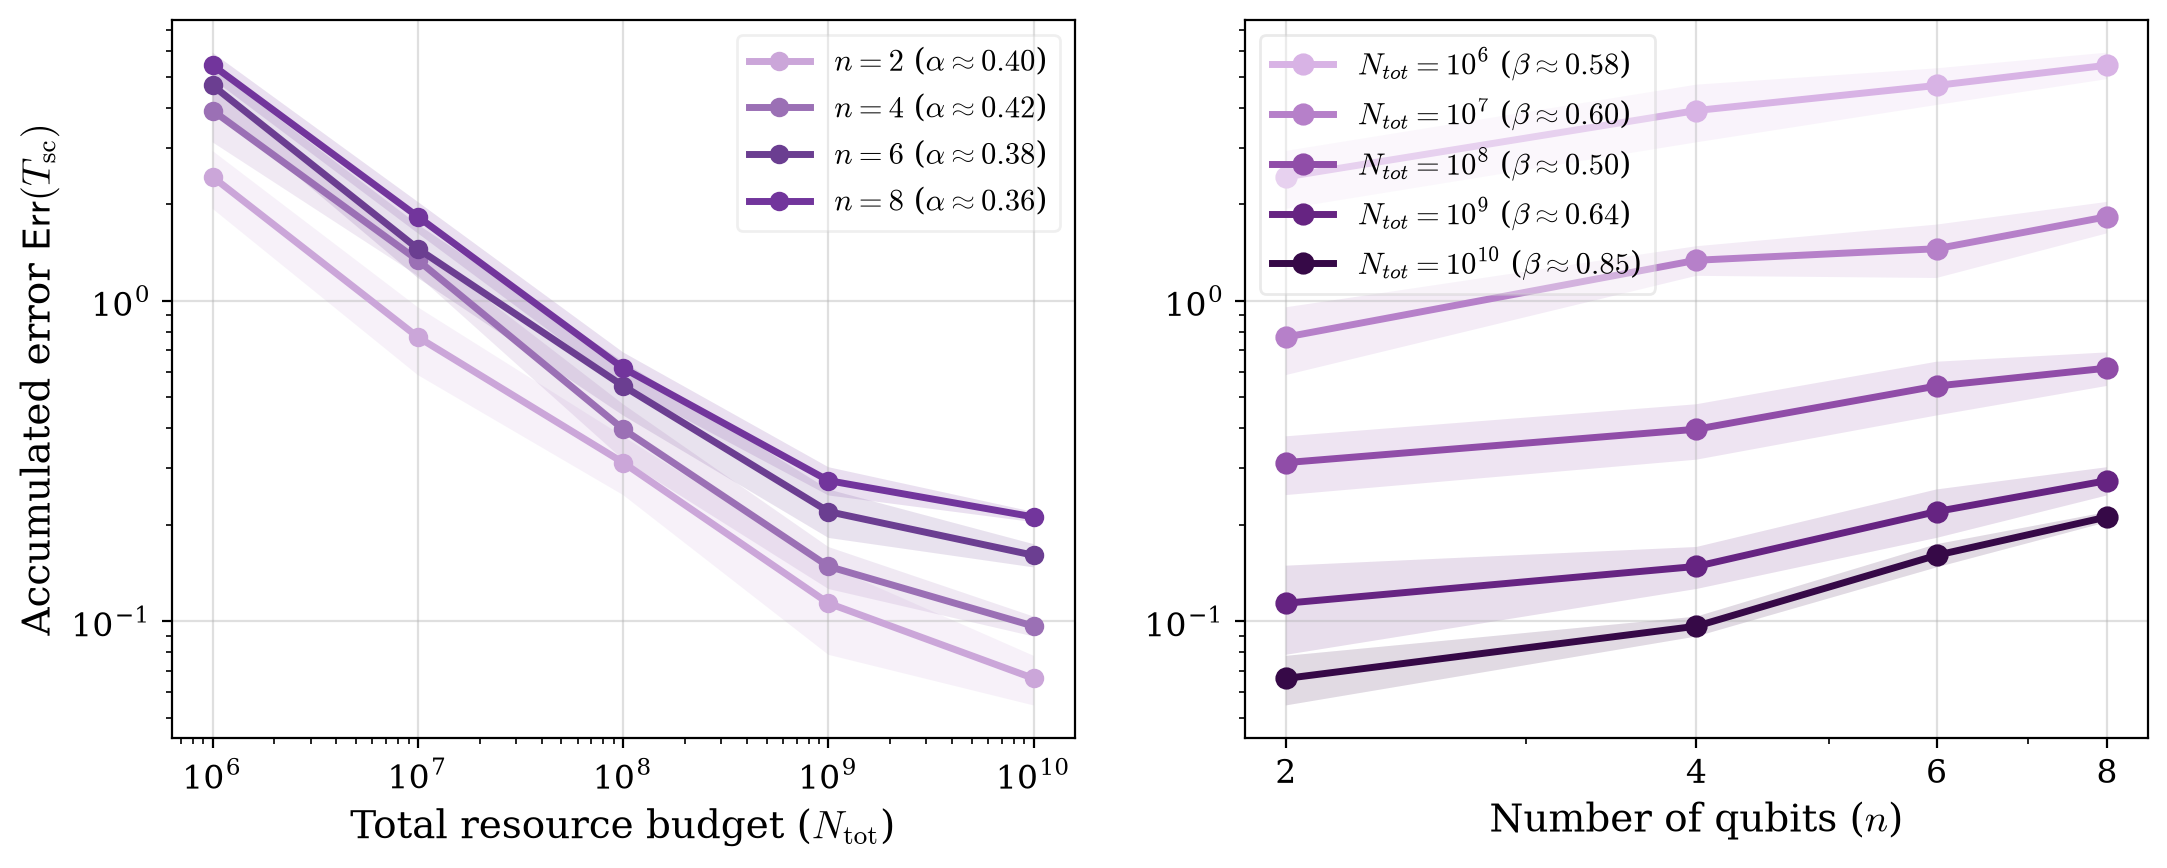

In [ ]:
plt.rcParams.update({
    "text.usetex": False,                 
    "mathtext.fontset": "cm",             
    "font.family": "serif",               
    "axes.labelsize": 14,  
    "axes.titlesize": 14,
    "font.size": 12,
    "legend.fontsize": 11,  
    "xtick.labelsize": 12,  
    "ytick.labelsize": 12   
})
# ---------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), dpi=200)

# =========================================================
# PANEL (a): Error vs Total Resource Budget (N_total)
# =========================================================
ax1 = axes[0]
colors_a = {2: '#cba6d9', 4: '#9b70b5', 6: '#6b3e91', 8: "#72359c"}

# Assuming N_total_list and alpha_fits are already defined in your environment
for n_qubits in [2, 4, 6, 8]:
    means = np.array(mean_errors[n_qubits])
    stds = np.array(std_errors[n_qubits])
    
    lower_bound = np.maximum(means - stds, 1e-10)
    upper_bound = means + stds
    
    ax1.loglog(N_total_list, means, 'o-', color=colors_a[n_qubits], lw=2.5, markersize=6,
               label=f'$n={n_qubits}$ ($\\alpha \\approx {alpha_fits[n_qubits]:.2f}$)')
    ax1.fill_between(N_total_list, lower_bound, upper_bound, color=colors_a[n_qubits], alpha=0.15, edgecolor='none')

# ax1.text(0.03, 0.95, r'\textbf{(a)}', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')
ax1.set_xlabel(r'Total resource budget ($N_\text{tot}$)')
ax1.set_ylabel(r'Accumulated error $\mathsf{Err}(T_\text{sc})$')

ax1.grid(True, which="major", ls="-", alpha=0.4, linewidth=0.8)
ax1.grid(False, which="minor")
ax1.legend(loc='upper right', framealpha=0.3)


# =========================================================
# PANEL (b): Error vs Number of Qubits (n)
# =========================================================
ax2 = axes[1]

n_array = np.array(sorted(list(mean_errors.keys())))
N_total_fixed = [int(1e6), int(1e7), int(1e8), int(1e9), int(1e10)]

colors_b = ['#d8b3e5', '#b680c9', '#904da8', '#662482', '#360947']

for i, N_total in enumerate(N_total_fixed):
    extracted_means = np.array([mean_errors[n][i] for n in n_array])
    extracted_stds = np.array([std_errors[n][i] for n in n_array])
    
    # Fit the spatial scaling exponent (beta)
    log_n = np.log(n_array)
    log_E = np.log(extracted_means)
    beta_fit = np.polyfit(log_n, log_E, 1)[0]
    
    exponent = int(np.log10(N_total))
    ax2.loglog(n_array, extracted_means, 'o-', color=colors_b[i], lw=2.5, markersize=7,
               label=f'$N_{{tot}}=10^{{{exponent}}}$ ($\\beta \\approx {beta_fit:.2f}$)')
    
    # Shaded variance regions
    lower_bound = np.maximum(extracted_means - extracted_stds, 1e-10)
    upper_bound = extracted_means + extracted_stds
    ax2.fill_between(n_array, lower_bound, upper_bound, color=colors_b[i], alpha=0.15, edgecolor='none')

# ax2.text(0.03, 0.95, r'\textbf{(b)}', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')
ax2.set_xlabel(r'Number of qubits ($n$)')

# Force the x-axis to display exact integer qubit numbers cleanly
ax2.set_xticks(n_array)
ax2.set_xticklabels([str(n) for n in n_array])
ax2.xaxis.set_minor_formatter(plt.NullFormatter()) 

ax2.grid(True, which="major", ls="-", alpha=0.4, linewidth=0.8)
ax2.grid(False, which="minor")
ax2.legend(loc='upper left', framealpha=0.4)


# =========================================================
# Final Layout Adjustments & Export
# =========================================================
plt.tight_layout(w_pad=2.0)
plt.savefig("sample_complexity_combined.pdf", bbox_inches="tight")
plt.savefig("sample_complexity_combined.png", dpi=600, bbox_inches="tight")
plt.show()